# Rotación de un Púlsar

Un púlsar es una estrella de neutrones altamente magnetizada que rota rápidamente y emite radiación periódica.

La rotación se describe mediante la fase:

\[
\phi(t) = \phi_0 + 2\pi \left[ F_0 t' + \frac{1}{2}F_1 t'^2 + \frac{1}{6}F_2 t'^3 + \frac{1}{24}F_3 t'^4 \right]
\]

donde:
- \( t' = (t - PEPOCH) \) en segundos
- \( F_0 \): frecuencia
- \( F_1, F_2, F_3 \): derivadas de la frecuencia

---

## Derivadas

Primera derivada:
\[
\dot{\phi}(t) = 2\pi \left[ F_0 + F_1 t' + \frac{1}{2}F_2 t'^2 + \frac{1}{6}F_3 t'^3 \right]
\]

Segunda derivada:
\[
\ddot{\phi}(t) = 2\pi \left[ F_1 + F_2 t' + \frac{1}{2}F_3 t'^2 \right]
\]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [10]:
# -------------------------------------------------------
# Función para leer un archivo .par (parámetros de púlsar)
# -------------------------------------------------------
def leer_par(filename):
    params = {}  # Diccionario donde guardaremos los parámetros

    # Abrimos el archivo en modo lectura
    with open(filename, 'r') as f:
        for line in f:
            # Eliminamos backslashes (\) y espacios al inicio/final
            line = re.sub(r'\\', '', line).strip()
            
            # Saltar líneas vacías o comentarios
            if not line or line.startswith("#"):
                continue
                
            # Separar la línea en palabras (por espacios)
            parts = line.split()
            
            # Verificar que haya al menos clave y valor
            if len(parts) >= 2:
                key = parts[0]       # Nombre del parámetro (ej: F0, F1, etc.)
                val_str = parts[1]   # Valor como string
                
                try:
                    # Ignorar coordenadas tipo RAJ/DECJ (tienen formato hh:mm:ss)
                    if ':' in val_str:
                        continue
                    
                    # Convertir el valor a float y guardarlo
                    params[key] = float(val_str)

                except ValueError:
                    # Si no se puede convertir (ej: nombre del púlsar), se ignora
                    pass

    return params  # Retorna el diccionario con los parámetros


# -------------------------------------------------------
# Función para calcular la fase del púlsar
# -------------------------------------------------------
def calcular_fase(t_mjd, params, phi0=0):
    # Obtener parámetros desde el diccionario
    # Si no existen, se usa 0 por defecto
    F0 = params.get("F0", 0.0)       # Frecuencia
    F1 = params.get("F1", 0.0)       # Primera derivada
    F2 = params.get("F2", 0.0)       # Segunda derivada
    F3 = params.get("F3", 0.0)       # Tercera derivada
    PEPOCH = params.get("PEPOCH", 0.0)  # Época de referencia

    # Convertir diferencia de tiempo de días (MJD) a segundos
    t = (t_mjd - PEPOCH) * 86400.0

    # -------------------------------
    # Fase (expansión de Taylor)
    # -------------------------------
    phi = phi0 + 2*np.pi * (
        F0*t +
        0.5*F1*t**2 +
        (1/6)*F2*t**3 +
        (1/24)*F3*t**4
    )

    # -------------------------------
    # Primera derivada (frecuencia angular)
    # -------------------------------
    phi_dot = 2*np.pi * (
        F0 +
        F1*t +
        0.5*F2*t**2 +
        (1/6)*F3*t**3
    )

    # -------------------------------
    # Segunda derivada
    # -------------------------------
    phi_ddot = 2*np.pi * (
        F1 +
        F2*t +
        0.5*F3*t**2
    )

    # Retornar todos los resultados
    return t, phi, phi_dot, phi_ddot


# -------------------------------------------------------
# EJEMPLO DE USO
# -------------------------------------------------------

# Leer archivo de parámetros
params = leer_par("posg.par")

# Mostrar parámetros cargados (para verificar)
print("Parámetros leídos:")
for k, v in params.items():
    print(k, "=", v)

# Elegir un tiempo en MJD
t_mjd = 58000  # puedes cambiarlo según tu caso

# Calcular fase
t, phi, phi_dot, phi_ddot = calcular_fase(t_mjd, params)

# Mostrar resultados
print("\nResultados:")
print(f"t (s): {t}")
print(f"φ (fase): {phi}")
print(f"φ̇ (frecuencia angular): {phi_dot}")
print(f"φ̈ (segunda derivada): {phi_ddot}")

Parámetros leídos:
F0 = 61.88404726894926
F1 = -1.9989467063920143e-10
F2 = 7.810093326935054e-21
F3 = 0.0
PEPOCH = 60379.0
POSEPOCH = 60379.0
DMEPOCH = 60379.0
DM = 0.0
PMRA = 0.0
PMDEC = 0.0
PX = 0.0
START = 60401.22127398062
FINISH = 60584.31296052359
TZRMJD = 60502.67873956879
TZRFRQ = 0.0
TRES = 126.032
EPHVER = 5.0
NE_SW = 4.0
MODE = 1.0
NITS = 1.0
NTOA = 6.0
CHI2R = 8.3104

Resultados:
t (s): -205545600.0
φ (fase): -79948679930.3969
φ̇ (frecuencia angular): 389.0881333638441
φ̈ (segunda derivada): -1.266061845416872e-09


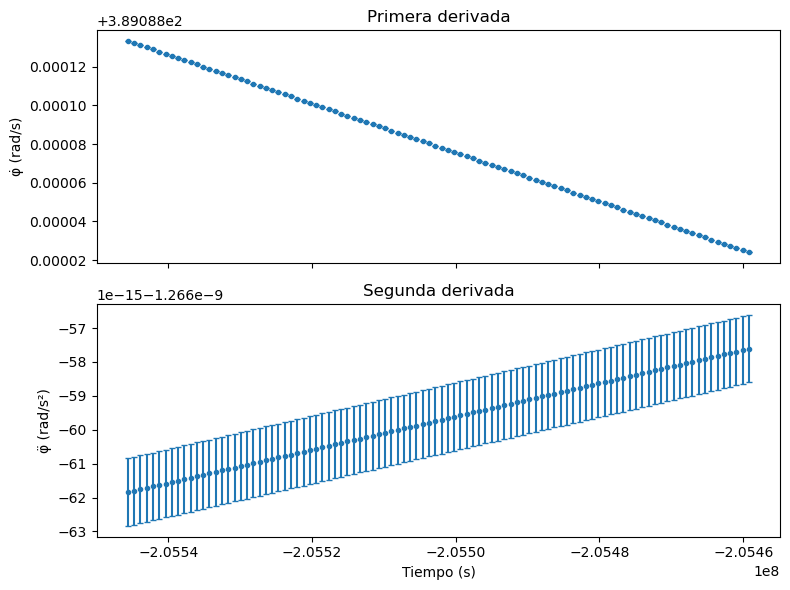

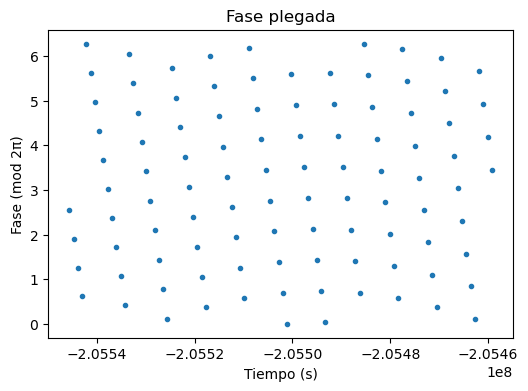

interactive(children=(FloatSlider(value=61.88404726894926, description='F0', max=68.07245199584419, min=55.695…

<function __main__.explorar(F0, F1)>

In [14]:
#Codigo del chatgpt arreglando todo lo de abajo
import matplotlib.pyplot as plt
from ipywidgets import interact
import numpy as np

# -------------------------------------------------------
# GENERAR VARIOS TIEMPOS (IMPORTANTE)
# -------------------------------------------------------
# Antes usabas un solo t_mjd → ahora usamos un rango
t_mjd_array = np.linspace(58000, 58001, 100)  # 100 puntos en 1 día

# Calcular fase para todos los tiempos
t, phi, phi_dot, phi_ddot = calcular_fase(t_mjd_array, params)

# -------------------------------------------------------
# ERRORES (SIMPLIFICADOS)
# -------------------------------------------------------
# ❌ Eliminamos t_err porque no existía
# ✔ Asignamos errores constantes pequeños

error_dot = np.full_like(phi_dot, 1e-10)     # error en φ̇
error_ddot = np.full_like(phi_ddot, 1e-15)   # error en φ̈

# -------------------------------------------------------
# GRÁFICOS DE DERIVADAS
# -------------------------------------------------------
fig, axs = plt.subplots(2, 1, figsize=(8,6), sharex=True)

# φ̇
axs[0].errorbar(t, phi_dot, yerr=error_dot,
                fmt='o', markersize=3, capsize=2)
axs[0].set_ylabel("φ̇ (rad/s)")
axs[0].set_title("Primera derivada")

# φ̈
axs[1].errorbar(t, phi_ddot, yerr=error_ddot,
                fmt='o', markersize=3, capsize=2)
axs[1].set_ylabel("φ̈ (rad/s²)")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_title("Segunda derivada")

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# FASE PLEGADA
# -------------------------------------------------------
# ✔ Reduce la fase al rango [0, 2π]
phi_mod = np.mod(phi, 2*np.pi)

plt.figure(figsize=(6,4))
plt.plot(t, phi_mod, '.')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fase (mod 2π)")
plt.title("Fase plegada")
plt.show()

# -------------------------------------------------------
# INTERACTIVIDAD
# -------------------------------------------------------
def explorar(F0, F1):
    # Copiar parámetros originales
    params_mod = params.copy()

    # Modificar valores
    params_mod["F0"] = F0
    params_mod["F1"] = F1

    # Recalcular
    t, _, phi_dot, _ = calcular_fase(t_mjd_array, params_mod)

    # Graficar
    plt.figure(figsize=(6,4))
    plt.plot(t, phi_dot, '.')
    plt.title("φ̇ interactivo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("φ̇ (rad/s)")
    plt.show()

def explorar(F0, F1):
    params_mod = params.copy()
    params_mod["F0"] = F0
    params_mod["F1"] = F1

    t, _, phi_dot, _ = calcular_fase(t_mjd_array, params_mod)

    plt.figure(figsize=(6,4))
    plt.plot(t, phi_dot, '.')
    plt.title("φ̇ interactivo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("φ̇ (rad/s)")
    plt.show()


# ✔ Obtener F1 (puede no existir)
F1_base = params.get("F1", 0.0)

# ✔ Construir rango correctamente (maneja negativos)
F1_min = min(F1_base*0.9, F1_base*1.1)
F1_max = max(F1_base*0.9, F1_base*1.1)

# ✔ SOLO UNA LLAMADA A interact (la correcta)
interact(explorar,
         F0=(params["F0"]*0.9, params["F0"]*1.1),
         F1=(F1_min, F1_max))

In [ ]:
# Si no hay errores, asignar pequeños valores
if t_err is None:
    error_dot = np.full_like(phi_dot, 1e-10)
    error_ddot = np.full_like(phi_ddot, 1e-15)
else:
    # Propagación simple (puedes mejorar esto)
    error_dot = np.full_like(phi_dot, 1e-10)
    error_ddot = np.full_like(phi_ddot, 1e-15)

fig, axs = plt.subplots(2, 1, figsize=(8,6), sharex=True)

# Primera derivada
axs[0].errorbar(t, phi_dot, yerr=error_dot, fmt='o', markersize=3, capsize=2)
axs[0].set_ylabel("φ̇ (rad/s)")
axs[0].set_title("Primera derivada")

# Segunda derivada
axs[1].errorbar(t, phi_ddot, yerr=error_ddot, fmt='o', markersize=3, capsize=2)
axs[1].set_ylabel("φ̈ (rad/s²)")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_title("Segunda derivada")

plt.tight_layout()
plt.show()

In [ ]:
phi_mod = np.mod(phi, 2*np.pi)

plt.figure(figsize=(6,4))
plt.plot(t, phi_mod, '.')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fase (mod 2π)")
plt.title("Fase plegada")
plt.show()

In [ ]:
from ipywidgets import interact

def explorar(F0, F1):
    params_mod = params.copy()
    params_mod["F0"] = F0
    params_mod["F1"] = F1

    t, phi, phi_dot, phi_ddot = calcular_fase(t_mjd, params_mod)

    plt.figure(figsize=(6,4))
    plt.plot(t, phi_dot, '.')
    plt.title("φ̇ interactivo")
    plt.show()

interact(explorar,
         F0=(params["F0"]*0.9, params["F0"]*1.1),
         F1=(params["F1"]*1.1, params["F1"]*0.9))

# Aplicación interactiva (idea)

Se puede construir una aplicación usando Streamlit que permita:

- Subir archivos `.par` y `.dat`
- Modificar parámetros:
  - F0, F1, F2, F3
  - PEPOCH
- Generar gráficos de:
  - Primera derivada (φ̇)
  - Segunda derivada (φ̈)
- Mostrar fase plegada
- Visualizar imagen de un púlsar

Esto permite explorar cómo cambian las propiedades rotacionales del púlsar.